# Transformers desde (casi) cero — WikiCAT_esv2

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leoe21/machine_learning_fundamentals/blob/main/03_unidad/RNN_Text/Sesion3/1-transformers-from-scratch-homework.ipynb)

En este notebook implementaremos un clasificador de textos en español utilizando transformers sobre el **mismo dataset que la Sesión 2 (LSTM)**: **WikiCAT_esv2** (resúmenes de Wikipedia, 12 categorías temáticas). Así podemos comparar LSTM vs Transformer en la misma tarea.

**Estructura del notebook:**
1. **Parte 1 — Transformer desde cero**: carga de WikiCAT_esv2, tokenizador BPE propio, bloques de atención y clasificador. Con ~6.7k ejemplos el accuracy en test suele ser bajo (~18%); sirve para entender la arquitectura.
2. **Parte 2 — Fine-tuning BETO**: uso de un BERT en español preentrenado (BETO) con el `Trainer` de Hugging Face. Aquí se obtiene un accuracy útil en test (~78%), comparable o mejor que la LSTM (~70%).

#### Referencias
- Dataset: https://huggingface.co/datasets/PlanTL-GOB-ES/WikiCAT_esv2
- [Attention is All You Need](http://arxiv.org/abs/1706.03762)
- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)
- [Tutorial 5: Transformers and Multi-Head Attention](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/05-transformers-and-MH-attention.html)

In [95]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

In [96]:
#!test '{IN_COLAB}' = 'True' && wget  https://github.com/leoe21/machine_learning_fundamentals/raw/main/requirements.txt && pip install -r requirements.txt
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y
!test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 -y
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
!test '{IN_COLAB}' = 'True' && pip install lightning datasets 'transformers[torch]' sentence-transformers

'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.


'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.


### Cargando el dataset WikiCAT_esv2
Mismo dataset que en el notebook LSTM (Sesión 2): resúmenes de artículos de Wikipedia en español, cada uno con una etiqueta entre 12 categorías (Religión, Economía, Historia, etc.). Campos: `text` y `label` (0-11).

In [97]:
from datasets import load_dataset
import warnings
import os

warnings.filterwarnings("ignore")
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
dataset = load_dataset('PlanTL-GOB-ES/WikiCAT_esv2', split='train')
dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 6716
})

Observemos uno de sus registros...

In [98]:
dataset[0]

{'text': 'En estadística, un modelo probit es un tipo de regresión donde la variable dependiente puede tomar solo dos valores, por ejemplo, casados o no casados. La palabra es un acrónimo, viene de probabilidad + unit (unidad).[1]\u200b El propósito del modelo es estimar la probabilidad de que una observación con características particulares caerá en una categoría específica; además, clasificando las observaciones basadas en sus probabilidades predichas es un tipo de modelo de clasificación binario .\nUn modelo probit es una especificación popular para un modelo de respuesta ordinal[2]\u200b o binario. Como tal, trata el mismo conjunto de problemas que la regresión logística utilizando técnicas similares. El modelo probit, que emplea una función de enlace probit, se suele estimar utilizando el procedimiento estándar de máxima verosimilitud , que se denomina una regresión probit.\nLos modelos Probit fueron presentados por Chester Bliss en 1934;[3]\u200b  Ronald Fisher propuso un método 

Para los efectos de esta tarea, nos servirán el texto y la categoría naturalmente.

A manera general, observemos que tan largos o cortos tienden a ser los textos.

In [99]:
text_lengths = [len(row['text']) for row in dataset]
print(f"Texto más corto: {min(text_lengths)}")
print(f"Texto más largo: {max(text_lengths)}")
print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths)}")

Texto más corto: 54
Texto más largo: 14966
Longitud promedio: 1035.9082787373436


Estos valores son la cantidad de *caracteres* de cada resumen. WikiCAT_esv2 tiene ~6.7k ejemplos. Usaremos una longitud máxima de **256 tokens** (como en el notebook LSTM) para poder comparar y mantener el entrenamiento manejable.

## Definiendo el Tokenizer

Entrenamos un tokenizador BPE basado en GPT-2 sobre el corpus WikiCAT. Como el dataset es pequeño (~6716 textos), usamos todo el corpus. Vocabulario de 50k tokens.

In [100]:
from tqdm.auto import tqdm
from transformers import AutoTokenizer
from transformers.models.gpt2.tokenization_gpt2 import bytes_to_unicode

length = len(dataset)  # WikiCAT_esv2: 6716 ejemplos
tokenizer = AutoTokenizer.from_pretrained("gpt2")

byte_to_unicode_map = bytes_to_unicode()
unicode_to_byte_map = dict((v, k) for k, v in byte_to_unicode_map.items())
base_vocab = list(unicode_to_byte_map.keys())

def batch_iterator(batch_size: int = 10):
    for i in tqdm(range(0, length, batch_size)):
        yield [dataset[j]['text'] for j in range(i, min(i + batch_size, length))]

spanish_news_tokenizer = tokenizer.train_new_from_iterator(batch_iterator(), vocab_size=50000, initial_alphabet=base_vocab)


100%|██████████| 672/672 [00:01<00:00, 445.68it/s]


Exploremos ahora el tokenizador obtenido.

In [101]:
tokens = sorted(spanish_news_tokenizer.vocab.items(), key=lambda x: x[1], reverse=False)
print(f"Vocabulario: {spanish_news_tokenizer.vocab_size} tokens")
print("Primeros 15 tokens:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[:15]])
print("15 tokens de en medio:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[1000:1015]])
print("Últimos 15 tokens:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[-15:]])

Vocabulario: 50000 tokens
Primeros 15 tokens:
['<|endoftext|>', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.']
15 tokens de en medio:
['ino', ' uno', 'ora', ' donde', 'displa', 'ystyle', 'displaystyle', ' Ch', 'cias', ' mismo', ' conj', ' todo', '\n  \n    ', '\n      \n    ', '\n  \n    \n    ']
Últimos 15 tokens:
['illaje', ' Inglesa', ' centralista', ' Adul', ' Adquisición', ' Adallom', ' Adonai', ' dimension', ' manifeste', ' manifestante', ' manifestada', 'νο', 'νά', ' ecumenismo', ' sensu']


Vemos que los primeros tokens corresponden a caracteres especiales y puntiación. Luego en el medio tenemos una combinación entre palabras completas y cortadas, el tokenizador se encarga de encontrar las frecuencias más comunes y asi partir las palabras por aquellas partes que tienden a repetirse mas. Esto es muy útil para trabajar con modelos de lenguaje ya que el modelo se vuelve robusto a diferentes ramificaciones de palabras e incluso a errores de tipografía. Finalmente, al final, vemos que tenemos más palabras cortadas y palabras muy especiales. Algo importante aquí es que podamos ver que los tokens tienen sentido con respecto a nuestro corpus.

Ahora veamos como convierte el tokenizador una oración muy sencilla:

In [102]:
spanish_news_tokenizer.pad_token = '[PAD]'
spanish_news_tokenizer("hola mundo!", max_length=8, truncation=True, padding='max_length')

{'input_ids': [72, 3147, 999, 1, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 0, 0, 0, 0]}

Lo que obtenemos de vuelta son los ids de cada token según el vocabulario. Ahora algo importante que notamos aquí es el *padding*, durante el entrenamiento, queremos que las secuencias sean de tamaño fijo, para asi operar comodamente con matrices. Pero ya vimos que no todos los textos tienen la misma longitud. Entonces que hacer? para los que son más largos que una longitud dada simplemente cortamos, pero para los que son más cortos, debemos *rellenar* lo faltante con un *token especial de relleno o padding*. Y es justo lo que definimos allí, cuando la cadena es inferior a 8 **tokens**, entonces debemos hacer padding hasta que se cumplan los 8.

Ahora, notemos que "hola mundo!" son 2 palabras, 9 letras, 1 espacio y 1 simbolo para un total de 11 caracteres, pero vemos que el resultado son 4 tokens y el padding. Esto es trabajo del tokenizador. Cuando lo entrenamos con nuestro corpus, el tokenizador computó las frecuencias de palabras y sus partes, tal como vimos arriba, entonces, estos tokens juntos forman la frase original, observemos:

In [103]:
spanish_news_tokenizer("hola mundo!", max_length=8, truncation=True, padding='max_length').tokens()

['h', 'ola', 'Ġmundo', '!', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

Claramente vemos los 4 tokens como cadenas independientes.

### Definiendo el dataset de pytorch
Ahora podemos proceder a definir el dataset. Esto debería ser muy sencillo dado que nuestro dataset es pequeño y ya tenemos el tokenizador listo.

In [104]:
import torch
import numpy as np
from typing import Tuple, Dict
from torch.utils.data import Dataset

class WikiCATDataset(Dataset):
    """Dataset para WikiCAT_esv2: text y label (0-11)."""

    def __init__(self, tokenizer, dataset, seq_length: int = 256):
        self.tokenizer = tokenizer
        self.tokenizer.pad_token = '[PAD]'
        self.dataset = dataset
        self.seq_length = seq_length
        self.num_classes = len(dataset.features["label"].names)
        self.id2label = dataset.features["label"].names

    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        text = self.dataset[index]['text']
        y = self.dataset[index]['label']
        data = {k: torch.tensor(v) for k, v in self.tokenizer(text, max_length=self.seq_length, truncation=True, padding='max_length').items()}
        data['y'] = torch.tensor(y)
        return data


    def __len__(self):
        return len(self.dataset)

In [105]:
# Pesos por clase (como en el LSTM) para compensar desbalance en las 12 categorías
import numpy as np
train_labels = [dataset[i]['label'] for i in train_dataset.indices]
class_counts = np.bincount(train_labels, minlength=wikicat_dataset.num_classes)
total = len(train_labels)
class_weights = total / (wikicat_dataset.num_classes * class_counts)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print("Pesos por clase:", class_weights_tensor)

Pesos por clase: tensor([1.9467, 3.5256, 1.0413, 0.5528, 0.4630, 0.7628, 0.9251, 1.0610, 1.6960,
        1.0686, 1.3992, 1.4305], device='cuda:0')


Instanciamos el dataset con **256 tokens** de longitud máxima (igual que en el notebook LSTM) para comparar resultados.

In [106]:
# Requiere haber ejecutado antes: carga de dataset, entrenamiento del tokenizer y celda con class WikiCATDataset
max_len = 256
wikicat_dataset = WikiCATDataset(spanish_news_tokenizer, dataset, seq_length=max_len)
assert len(wikicat_dataset) == len(dataset)

Y luego, procedemos a hacer el train-val-test split y crear los dataloaders.

In [107]:
import torch
from torch.utils.data import random_split
from torch.utils.data import DataLoader

batch_size = 4 if not IN_COLAB else 12
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Usando dispositivo:', device)

train_dataset, val_dataset, test_dataset = random_split(wikicat_dataset, lengths=[0.8, 0.1, 0.1])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

Usando dispositivo: cuda


### Definición de los Positional Embeddings

Según el paper, los autores agregan una secuencia sinusoidal a los embeddings de los tokens con el fin de inyectar información referente a la posición de cada token en las frases. Esto obedece a la definición:

$$
PE(pos, 2i) = \sin(pos/10000^{2i/d_{model}}) \\
PE(pos, 2i + 1) = \cos(pos/10000^{2i/d_{model}})
$$

Donde: 
- $pos$ es la posición del *token* en la secuencia.
- $i$ es la dimensión $i$ en el embedding $d$.
- $d_model$ es la dimensionalidad total del embedding.

Lo que los autores propusieron fue que para las posiciones pares, se calculara el seno de la posición, relativa a la dimensionalidad del embedding y para las posiciones impares, se calculara el coseno. Según los autores, estos tenían la hipótesis de que estas funciones inyectarían la información posicional relativa de forma eficiente, en parte porque se pueden pre-calcular e inyectar directamente durante el entrenamiento, evitando asi emplear recursos en entrenar estructuras para aprenderlos.

Esto último es particularmente importante ya que se evita tanto hacer uso de recursos innecesarios como acelerar el proceso de entrenamiento al no tener que computar gradientes para esta parte. Sin embargo, los autores también mencionaron que es ciertamente posible aprender estos positional embeddings como parte del entrenamiento y que según sus resultados, no había mucha diferencia entre ambos enfoques, razón por la cual, se prefiere el positional encoding sinusoidal.

In [108]:
import numpy as np
import torch.nn as nn
from enum import Enum
from typing import Optional


class PosEncodingType(Enum):
    SINUSOID = 1
    LEARNABLE = 2


class SinusoidPE(nn.Module):

    def __init__(self, max_len: int, d_model: int):
        super(SinusoidPE, self).__init__()
        
        # Definimos un vector columna con las posiciones de la secuencia de entrada (pos)
        pos = torch.arange(max_len).unsqueeze(1)
        # Definimos un vector de fila con las dimensiones del embedding (i)
        i = torch.arange(d_model).unsqueeze(0)

        # Calculamos el denominador segun la formula
        div_term = 1 / torch.pow(10000, (2 * (i // 2)) / torch.tensor(d_model, dtype=torch.float32))
        # Aplicamos el denominador a las posiciones
        angle_rads = pos * div_term

        # Inicializamos la matriz de positional encodings
        pos_encoding = torch.zeros(max_len, d_model)
        # Calculamos los embeddings para los numeros pares con seno: PE(pos, 2i)
        pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        # Calculamos los embdeddings para los numeros inpares con coseno: PE(pos, 2i+1)
        pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])
        
        # Registramos la variable como atributo de clase
        self.register_buffer("pos_encoding", pos_encoding.unsqueeze(0), persistent=False)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pos_encoding[:, :x.size(1), :]
    

class LearnablePE(nn.Module):

    def __init__(self, vocab_size: int, d_model: int, max_len: int = float('-inf')):
        super(LearnablePE, self).__init__()
        self.max_len = max_len
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        positions = torch.arange(0, max(x.size(-1), self.max_len))
        pos_emb = self.embedding(positions)
        return x + pos_emb



class TokenAndPosEmbedding(nn.Module):

    def __init__(self, max_len: int, embed_dim: int, vocab_size: int, pos_encoding_type: PosEncodingType = PosEncodingType.SINUSOID):
        super(TokenAndPosEmbedding, self).__init__()
        self.token_emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
        if pos_encoding_type == PosEncodingType.SINUSOID:
            self.pos_emb = SinusoidPE(max_len, embed_dim)
        else:
            self.pos_emb = LearnablePE(vocab_size, embed_dim)


    def forward(self, x):
        token_emb = self.token_emb(x)
        return self.pos_emb(token_emb)

        

Ahora procedemos a instanciar el modulo que va a convertir los tokens en embeddings con positional embeddings.

In [109]:
# Modelo compacto (emb_dim=64, 4 heads) para ~6.7k ejemplos: menos parámetros => mejor generalización
emb_dim = 64
tpe = TokenAndPosEmbedding(max_len, emb_dim, spanish_news_tokenizer.vocab_size)
pos_encoding = tpe.pos_emb.pos_encoding.squeeze(0).numpy()


A manera exploratoria, podemos observar gráficamente en que consisten estos vectores. En el siguiente gráfico podemos observar como los valores tienden a oscilar para diferentes posiciones en la dimensionalidad del embedding. Los valores individuales no tienen una interpretación directa, pero lo que vale la pena resaltar es que se observa una "transición" a medida que nos desplazamos por las dimensiones del embedding y sus respectivas posiciones, no es solo ruido.

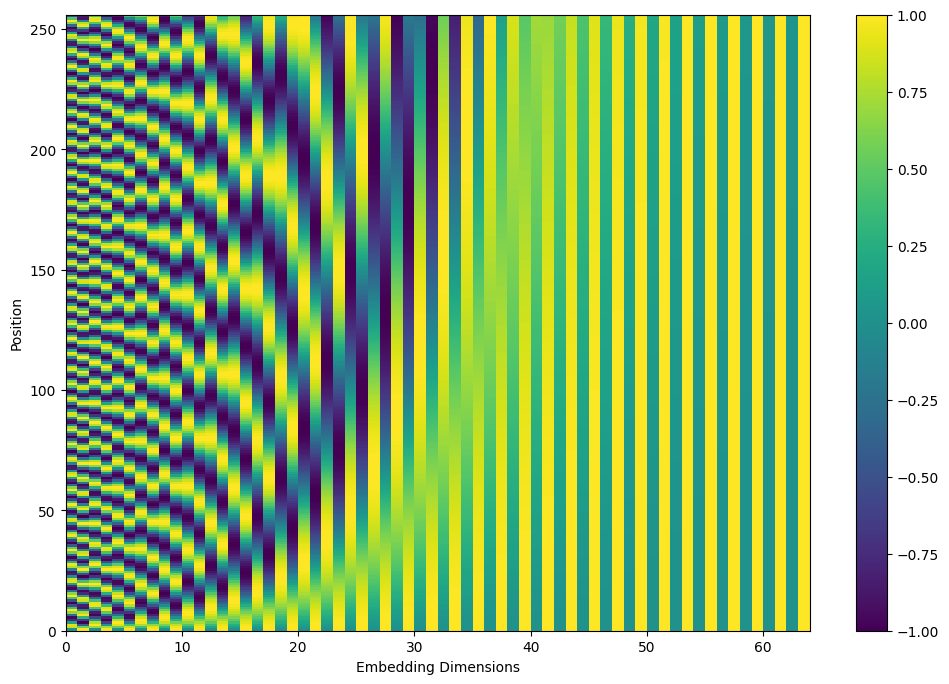

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.pcolormesh(pos_encoding, cmap='viridis')
plt.xlabel('Embedding Dimensions')
plt.xlim((0, emb_dim))
plt.ylabel('Position')
plt.colorbar()
plt.show()

Ahora, si pasamos nuestra frase simple por el tokenizador, deberíamos obtener una matriz con la forma: $(longitud, d_{model})$:

In [111]:
text = "hola mundo!"
tokens = spanish_news_tokenizer(text, max_length=max_len, truncation=True, padding='max_length')
x = torch.tensor(tokens['input_ids']).unsqueeze(0)
mask = torch.tensor(tokens['input_ids']).unsqueeze(0)
embedding = tpe(x)
embedding.shape

torch.Size([1, 256, 64])

### Multi-Head Attention

![](../assets/mh-attention.png)

Ahora procedemos a definir al núcleo del modelo. Recodemos que la atención se define por:

$$
\text{Attention}(Q, K, V) = \text{softmax}(\frac{QK^T}{\sqrt{d_K}})V
$$

Que es la definición de "Scaled Dot-Product Attention". Y Multi-Head Attention es la concatenación de varias cabezas ejecutando el mismo scaled dot-product sobre partes del input. Entonces tenemos:

In [112]:
import math


class MultiHeadAttention(nn.Module):

    def __init__(self, embed_size: int, num_heads: int = 8):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.num_heads = num_heads
        assert embed_size & num_heads == 0, 'El tamaño del embedding debería ser divisible por el numero de cabezas'
        self.projection_dim = embed_size // num_heads
        self.query = nn.Linear(emb_dim, emb_dim)
        self.key = nn.Linear(emb_dim, emb_dim)
        self.value = nn.Linear(emb_dim, emb_dim)
        self.comibe_heads = nn.Linear(emb_dim, emb_dim)


    @staticmethod
    def _scaled_dot_product(q, k, v, mask=None):
        """scaled dot product.

        Esta función define el bloque mencionado.
        Aquí se hace la multiplicación de matrices
        entre los Q, K y V para luego calcular el 
        score de atención.

        Nótese además que aquí aplicamos una máscara
        de atención. Esto se debe a que como estamos
        rellenando las cadenas cortas con un token que
        en si mismo no trae ningún significado, no queremos
        que la red desperdicie recursos operando sobre este
        token, entonces usamos la máscara para poner los valores
        de atención en numeros muy pequeños para que al
        calcular el score, estos no sobresalgan sobre los demás.
        """
        # d_k para el escalamiento
        d_k = q.size()[-1]

        # multiplicacion Q \cdot K^T 
        attn_logits = torch.matmul(q, k.transpose(-2, -1))
        # escalamiento
        attn_logits = attn_logits / math.sqrt(d_k)
        
        # Se aplica la máscara
        if mask is not None:
            attn_logits = attn_logits.masked_fill(mask.reshape(mask.shape[0], 1, 1, -1) == 0, -9e-15)

        # Se calcula el score de atención.
        attention = torch.softmax(attn_logits, dim=-1)
        # Se obtienen los valores tras el score de atención.
        values = torch.matmul(attention, v)
        return values, attention
    

    def _separate_heads(self, x, batch_size):
        # Llega: (batch, seq_len, emb_dim)
        x =  x.reshape(batch_size, -1, self.num_heads, self.projection_dim)  # (batch, seq_len, num_heads, emb_dim / num_heads)
        return x.permute(0, 2, 1, 3)  # (batch, num_heads, seq_len, emb_dim / num_heads)
    

    def forward(self, x, mask=None, return_attention=False):
        """forward

        Este es todo el forward pass del multi-head attention.
        Aquí se coordina el resto de las operaciones, como
        la concatenación de las múltiples cabezas como 
        el paso por la capa densa previo a entregar el
        resultado.
        """
        # x: (batch, seq_len, emb_dim)
        batch_size, seq_len, emb_dim = x.size()
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        q = self._separate_heads(q, batch_size)
        k = self._separate_heads(k, batch_size)
        v = self._separate_heads(v, batch_size)

        weights, attention = self._scaled_dot_product(q, k, v, mask)
        weights = weights.permute(0, 2, 1, 3) # (batch, seq_len, num_heads, emb_dim / num_heads)
        weights = weights.reshape(batch_size, seq_len, emb_dim)
        output = self.comibe_heads(weights)
        
        if return_attention:
            return output, attention
        else:
            return output


Podemos hacer una prueba rápida de que las operaciones funcionan a nivel de matrices.

In [113]:
mha = MultiHeadAttention(emb_dim)
mha(embedding, mask).shape

torch.Size([1, 256, 64])

### Definición del bloque transformers

![](../assets/transformers-achitecture.png)

Finalmente, definimos el bloque de transformers. Recordemos que como esta es una tarea de clasificación, solamente necesitamos el encoder, por lo que esto es silamente la primera parte del diseño de arquitecura de red.

En esta capa, simplemente ponemos una capa densa adicional junto con las normalizaciones a nivel de capa.

In [114]:
class TransformerBlock(nn.Module):

    def __init__(self, emb_dim: int, num_heads: int = 8):
        super(TransformerBlock, self).__init__()
        self.mhatt = MultiHeadAttention(emb_dim, num_heads)
        self.mhatt_dropput = nn.Dropout(0.2)
        self.ffn = nn.Sequential(
            nn.Linear(emb_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, emb_dim)
        )
        self.layer_norm1 = nn.LayerNorm(emb_dim)
        self.layer_norm2 = nn.LayerNorm(emb_dim)


    def forward(self, x, mask=None):
        attn_output = self.mhatt(x, mask)
        attn_output = self.mhatt_dropput(attn_output)
        attn_output = self.layer_norm1(attn_output)
        ffn_out = self.ffn(attn_output)
        return self.layer_norm2(ffn_out)


Nuevamente, probamos rapidamente para asegurarnos que las capas operan correctamente.

In [115]:
tb = TransformerBlock(emb_dim)
tb(embedding, mask).shape

torch.Size([1, 256, 64])

In [116]:
num_heads = 4  # emb_dim debe ser divisible por num_heads (64/4=16)
vocab_size = spanish_news_tokenizer.vocab_size

token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size).to(device)
transformer = TransformerBlock(emb_dim, num_heads).to(device)
ff = nn.Sequential(
    nn.Flatten(),
    nn.Linear(max_len * emb_dim, wikicat_dataset.num_classes)
).to(device)

In [117]:
it = iter(train_loader)
batch = next(it)
x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
x, mask = x.to(device), mask.to(device)

embeddings = token_embeddings(x)
assert embeddings.shape == (train_loader.batch_size, max_len, emb_dim)

attention = transformer(embeddings, mask)
print('Dispositivo de salida:', attention.device)
attention.shape

Dispositivo de salida: cuda:0


torch.Size([4, 256, 64])

In [118]:
ff = ff.to(device)
pred = ff(attention)
pred.shape

torch.Size([4, 12])

### Estrategia: por qué el transformer desde cero rinde menos que la LSTM

Con **~6.7k ejemplos** (WikiCAT_esv2), los transformers entrenados **desde cero** suelen quedar por debajo de una LSTM con **embeddings preentrenados** (Spacy). La literatura indica:
- Los transformers necesitan **muchos más datos** para aprender bien; con pocos datos, **LSTM + buenos embeddings** suele ganar.
- Para mejorar el from-scratch: **modelo más pequeño** (menos parámetros), **inicialización cuidadosa** (std=0.02 en embeddings) y **clasificador más simple** con más dropout.
- Para **superar el ~70%** del LSTM con transformers, la vía correcta es **fine-tunar un BERT/RoBERTa en español** (ej. PlanTL-GOB-ES en Hugging Face), no entrenar desde cero.

### Definición del clasificador

Finalmente, definimos el modelo en si. Este modelo constará de 3 capas:

- La tokenización, tal como la definimos anteriormente.
- El transformer, que acabamos de decinir.
- Una capa densa adicional que servirá como clasificador de aquello que nos entregue la capa del transformer.

Como este es un LightningModule, aquí definiremos el resto de funciones utilitarias para el entrenamiento de la tarea.

In [119]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torchmetrics import Accuracy


class SpanishNewsClassifier(LightningModule):

    def __init__(self, max_len: int, vocab_size: int, num_classes: int, emb_dim: int, num_heads: int = 8, class_weights=None):
        super(SpanishNewsClassifier, self).__init__()
        self.num_classes = num_classes
        self.class_weights = class_weights

        self.token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)
        nn.init.normal_(self.token_embeddings.token_emb.weight, mean=0.0, std=0.02)  # init tipo GPT para estabilidad
        self.transformer = TransformerBlock(emb_dim, num_heads)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(max_len * emb_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)


    def forward(self, x, mask=None):
        embeddings = self.token_embeddings(x)
        attention = self.transformer(embeddings, mask)
        return self.classifier(attention)
    

    def training_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        loss = F.cross_entropy(y_hat, y, weight=self.class_weights, label_smoothing=0.1)
        self.train_acc(y_hat, y)
        self.log('train-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train-acc', self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss
    
    def validation_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        loss = F.cross_entropy(y_hat, y, weight=self.class_weights, label_smoothing=0.1)
        self.val_acc(y_hat, y)
        self.log('val-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-acc', self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss
    
    def test_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        self.test_acc(y_hat, y)
        self.log('test-acc', self.test_acc, prog_bar=True, on_step=False, on_epoch=True)


    def predict_step(self, batch):
        x, mask = batch['input_ids'], batch['attention_mask']
        return self(x, mask)


    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=5e-4, weight_decay=1e-5)
        return optimizer
    

model = SpanishNewsClassifier(max_len=wikicat_dataset.seq_length, vocab_size=spanish_news_tokenizer.vocab_size, num_classes=wikicat_dataset.num_classes, emb_dim=emb_dim, num_heads=4, class_weights=class_weights_tensor)

tb_logger = TensorBoardLogger('tb_logs', name='TransformersClassifier')
callbacks=[EarlyStopping(monitor='val-loss', patience=7, mode='min')]
trainer = Trainer(max_epochs=40, devices=1, logger=tb_logger, callbacks=callbacks, precision="16-mixed", gradient_clip_val=1.0)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ token_embeddings │ TokenAndPosEmbedding │  3.2 M │ train │     0 │
│ 1 │ transformer      │ TransformerBlock     │ 83.0 K │ train │     0 │
│ 2 │ classifier       │ Sequential           │  4.2 M │ train │     0 │
│ 3 │ train_acc        │ MulticlassAccuracy   │      0 │ train │     0 │
│ 4 │ val_acc          │ MulticlassAccuracy   │      0 │ train │     0 │
│ 5 │ test_acc         │ MulticlassAccuracy   │      0 │ train │     0 │
└───┴──────────────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 7.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.5 M                                                                                                
Total estimated model params size (MB): 29                                                                         
Modules in train mode: 26                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Observemos el proceso de entrenamiento

In [120]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [121]:
%tensorboard --logdir tb_logs/

Reusing TensorBoard on port 6006 (pid 27136), started 0:25:50 ago. (Use '!kill 27136' to kill it.)

**Validación en test del transformer desde cero**

La siguiente celda evalúa el modelo **construido desde cero** (tokenizador BPE + bloques de atención + clasificador) en el conjunto de prueba. Con este dataset pequeño (~6.7k ejemplos) es normal obtener un **accuracy bajo (~18%)**; el modelo no llega a aprender bien las 12 categorías. Este resultado sirve para ver el límite del "from scratch" con pocos datos; los resultados útiles están en la sección de **fine-tuning BETO** más abajo.

In [122]:
model.eval()
trainer.test(model, test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test-acc          │    0.1818181872367859     │
└───────────────────────────┴───────────────────────────┘

[{'test-acc': 0.1818181872367859}]

### Haciendo predicciones

Finalmente, hacemos uso del modelo para clasificación temática (12 categorías de WikiCAT_esv2).

In [123]:
predictions = trainer.predict(model, test_loader)
predictions = torch.cat(predictions, dim=0)
predictions = torch.argmax(predictions, dim=-1)
predictions = [wikicat_dataset.id2label[pred] for pred in predictions.numpy()]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [124]:
import pandas as pd

test_indices = test_dataset.indices
df = pd.DataFrame(data={
    "texto": dataset[test_indices]['text'],
    "tokens": [spanish_news_tokenizer(v)['input_ids'] for v in dataset[test_indices]['text']],
    "categoría": [wikicat_dataset.id2label[l] for l in dataset[test_indices]['label']],
    'predicción': predictions
}, index=test_indices)

df['tokens_string'] = df.tokens.apply(lambda t: spanish_news_tokenizer.convert_ids_to_tokens(t))
df = df[["texto", "tokens", "tokens_string", "categoría", "predicción"]]
df.style.set_table_styles(
    [
        {'selector': 'td', 'props': [('word-wrap', 'break-word')]}
    ]
)
df.head(15)

Token indices sequence length is longer than the specified maximum sequence length for this model (1939 > 1024). Running this sequence through the model will result in indexing errors


,texto,tokens,tokens_string,categoría,predicción
2221,Se llama carta desaforada a la que se daba con...,"[1469, 2144, 6384, 6506, 9081, 273, 279, 303, ...","[Se, Ġllama, Ġcarta, Ġdesaf, orada, Ġa, Ġla, Ġ...",Derecho,Política
1921,«Sally's Pigeons» es un canción interpretada p...,"[3824, 51, 13246, 3881, 396, 15649, 6927, 645,...","[Â«, S, ally, 's, ĠP, ige, ons, Â», Ġes, Ġun, ...",Derecho,Política
962,Unwanted Advances: Sexual Paranoia Comes to Ca...,"[482, 87, 530, 68, 19182, 533, 26, 33517, 1328...","[Un, w, ante, d, ĠAdvan, ces, :, ĠSexual, ĠPar...",Historia,Política
6435,La crítica de la ciencia plantea los problemas...,"[480, 2473, 260, 279, 993, 6335, 317, 1716, 30...","[La, ĠcrÃŃtica, Ġde, Ġla, Ġciencia, Ġplantea, ...",Ciencia_y_Tecnología,Política
5600,Un Azul es un galardón que pueden obtener los ...,"[482, 40436, 291, 296, 13980, 303, 850, 2753, ...","[Un, ĠAzul, Ġes, Ġun, ĠgalardÃ³n, Ġque, Ġpuede...",Deporte,Política
381,Una carrera de rata es una búsqueda interminab...,"[1724, 4700, 260, 843, 306, 291, 335, 3601, 36...","[Una, Ġcarrera, Ġde, Ġra, ta, Ġes, Ġuna, ĠbÃºs...",Economía,Política
2971,«Delirio de Grandeza» es una canción del canta...,"[3824, 10878, 21845, 260, 14518, 596, 645, 291...","[Â«, Del, irio, Ġde, ĠGrande, za, Â», Ġes, Ġun...",Música,Política
2305,"En el derecho de daños, la negligencia profesi...","[619, 290, 1028, 260, 8816, 12, 279, 16717, 28...","[En, Ġel, Ġderecho, Ġde, ĠdaÃ±os, ,, Ġla, Ġneg...",Derecho,Política
1999,Una doctrina (del latín doctrīna) es un conjun...,"[1724, 3772, 344, 1443, 2060, 32012, 9, 291, 2...","[Una, Ġdoctrina, Ġ(, del, ĠlatÃŃn, ĠdoctrÄ«na,...",Derecho,Política
2360,"En matemáticas, la prueba de Lucas-Lehmer es u...","[619, 1642, 12, 279, 2969, 260, 8129, 13, 6059...","[En, ĠmatemÃ¡ticas, ,, Ġla, Ġprueba, Ġde, ĠLuc...",Matemáticas,Política


In [125]:
errors = df[df['categoría'] != df['predicción']]
errors.head(15)

,texto,tokens,tokens_string,categoría,predicción
2221,Se llama carta desaforada a la que se daba con...,"[1469, 2144, 6384, 6506, 9081, 273, 279, 303, ...","[Se, Ġllama, Ġcarta, Ġdesaf, orada, Ġa, Ġla, Ġ...",Derecho,Política
1921,«Sally's Pigeons» es un canción interpretada p...,"[3824, 51, 13246, 3881, 396, 15649, 6927, 645,...","[Â«, S, ally, 's, ĠP, ige, ons, Â», Ġes, Ġun, ...",Derecho,Política
962,Unwanted Advances: Sexual Paranoia Comes to Ca...,"[482, 87, 530, 68, 19182, 533, 26, 33517, 1328...","[Un, w, ante, d, ĠAdvan, ces, :, ĠSexual, ĠPar...",Historia,Política
6435,La crítica de la ciencia plantea los problemas...,"[480, 2473, 260, 279, 993, 6335, 317, 1716, 30...","[La, ĠcrÃŃtica, Ġde, Ġla, Ġciencia, Ġplantea, ...",Ciencia_y_Tecnología,Política
5600,Un Azul es un galardón que pueden obtener los ...,"[482, 40436, 291, 296, 13980, 303, 850, 2753, ...","[Un, ĠAzul, Ġes, Ġun, ĠgalardÃ³n, Ġque, Ġpuede...",Deporte,Política
381,Una carrera de rata es una búsqueda interminab...,"[1724, 4700, 260, 843, 306, 291, 335, 3601, 36...","[Una, Ġcarrera, Ġde, Ġra, ta, Ġes, Ġuna, ĠbÃºs...",Economía,Política
2971,«Delirio de Grandeza» es una canción del canta...,"[3824, 10878, 21845, 260, 14518, 596, 645, 291...","[Â«, Del, irio, Ġde, ĠGrande, za, Â», Ġes, Ġun...",Música,Política
2305,"En el derecho de daños, la negligencia profesi...","[619, 290, 1028, 260, 8816, 12, 279, 16717, 28...","[En, Ġel, Ġderecho, Ġde, ĠdaÃ±os, ,, Ġla, Ġneg...",Derecho,Política
1999,Una doctrina (del latín doctrīna) es un conjun...,"[1724, 3772, 344, 1443, 2060, 32012, 9, 291, 2...","[Una, Ġdoctrina, Ġ(, del, ĠlatÃŃn, ĠdoctrÄ«na,...",Derecho,Política
2360,"En matemáticas, la prueba de Lucas-Lehmer es u...","[619, 1642, 12, 279, 2969, 260, 8129, 13, 6059...","[En, ĠmatemÃ¡ticas, ,, Ġla, Ġprueba, Ġde, ĠLuc...",Matemáticas,Política


## Conclusiones

**Resumen de resultados en WikiCAT_esv2 (mismo dataset que la Sesión 2):**
- **Transformer desde cero** (este notebook): accuracy en test ~**18%**. Con ~6.7k ejemplos no es competitivo; ilustra el límite de entrenar un transformer from scratch con pocos datos.
- **Fine-tuning BETO** (sección siguiente): accuracy en test ~**78%**. Es la opción recomendable para obtener buenos resultados con transformers en esta tarea.
- **LSTM + embeddings preentrenados** (Sesión 2): accuracy en test ~**70%**. Comparable; BETO suele superarlo.

**Sobre la arquitectura y los datos:**
- Este notebook usa el **mismo dataset que la Sesión 2 (LSTM)**: WikiCAT_esv2 (12 categorías temáticas), para comparar LSTM vs Transformer en la misma tarea.
- Los transformers son muy potentes pero necesitan **muchos datos** o **modelos preentrenados**; con pocos ejemplos, una LSTM con buenos embeddings puede ganar al transformer from scratch.
- Los transformers son hambrientos de recursos; es necesario contar con hardware adecuado para acelerar el entrenamiento y a veces hasta poder acomodar el modelo en lo que se tenga disponible.
- Un factor decisivo es la calidad de los **embeddings**: un modelo con buenos embeddings (preentrenados o aprendidos con mucho dato) tiende a dar mejores resultados. Con pocos datos, conviene usar modelos preentrenados (p. ej. BETO) en lugar de entrenar desde cero.
- En las lecciones posteriores se parte de modelos pre-entrenados para adaptarlos a tareas específicas.
- En los errores del modelo from scratch puede fallar de forma llamativa; para analizarlos ayudan los scores de atención y revisar si la tokenización fue adecuada en esos casos.

## Alternativa: fine-tuning BERT español (resultados útiles)

El transformer **entrenado desde cero** con ~6.7k ejemplos suele dar accuracy bajo (incluso colapso a una clase). La forma de obtener **buen accuracy (~70% o más)** con transformers en este dataset es **fine-tunar un modelo preentrenado** en español (BETO / BERT). Aquí usamos **dccuchile/bert-base-spanish-wwm-cased** (BETO) y el `Trainer` de Hugging Face.

In [126]:
# Fine-tuning BETO (BERT español) sobre WikiCAT_esv2
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import load_dataset
import numpy as np

# Reutilizamos el mismo dataset WikiCAT_esv2
hf_dataset = load_dataset('PlanTL-GOB-ES/WikiCAT_esv2', split='train')
id2label = hf_dataset.features['label'].names
num_labels = len(id2label)
label2id = {v: k for k, v in enumerate(id2label)}

model_name = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer_bert = AutoTokenizer.from_pretrained(model_name)
model_bert = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels, id2label={i: id2label[i] for i in range(num_labels)}, label2id=label2id)

def tokenize_fn(examples):
    return tokenizer_bert(examples["text"], truncation=True, max_length=256, padding="max_length")

tokenized = hf_dataset.map(tokenize_fn, batched=True, remove_columns=["text"])
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch")
print("Dataset tokenizado:", tokenized)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 6716/6716 [00:02<00:00, 2730.05 examples/s]

Dataset tokenizado: Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6716
})


In [127]:
# Split 80/10/10 y entrenamiento
split = tokenized.train_test_split(test_size=0.2, seed=42)
train_ds = split["train"]
tmp = split["test"].train_test_split(test_size=0.5, seed=42)
val_ds = tmp["train"]
test_ds = tmp["test"]

training_args = TrainingArguments(
    output_dir="./wikicat_bert",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if hasattr(labels, 'numpy'):
        labels = labels.numpy()
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": float((preds == labels).mean())}

trainer_bert = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer_bert,
    compute_metrics=compute_metrics,
)
trainer_bert.train()

                                                  
 33%|███▎      | 336/1008 [01:02<02:10,  5.14it/s]

{'eval_loss': 0.7702454328536987, 'eval_accuracy': 0.7767857142857143, 'eval_runtime': 2.3963, 'eval_samples_per_second': 280.427, 'eval_steps_per_second': 17.527, 'epoch': 1.0}


 50%|████▉     | 501/1008 [01:35<01:39,  5.10it/s]

{'loss': 0.9314, 'grad_norm': 8.524494171142578, 'learning_rate': 1.007936507936508e-05, 'epoch': 1.49}


                                                  
 67%|██████▋   | 672/1008 [02:12<01:00,  5.52it/s]

...

                                                   
100%|██████████| 1008/1008 [03:25<00:00,  5.09it/s]

{'eval_loss': 0.7284730076789856, 'eval_accuracy': 0.7857142857142857, 'eval_runtime': 2.814, 'eval_samples_per_second': 238.806, 'eval_steps_per_second': 14.925, 'epoch': 3.0}


100%|██████████| 1008/1008 [03:26<00:00,  4.88it/s]

{'train_runtime': 206.5501, 'train_samples_per_second': 78.025, 'train_steps_per_second': 4.88, 'train_loss': 0.6773980806271235, 'epoch': 3.0}


TrainOutput(global_step=1008, training_loss=0.6773980806271235, metrics={'train_runtime': 206.5501, 'train_samples_per_second': 78.025, 'train_steps_per_second': 4.88, 'total_flos': 2120339243704320.0, 'train_loss': 0.6773980806271235, 'epoch': 3.0})

**Accuracy en test de BETO**

La siguiente celda evalúa el modelo **BETO fine-tuned** en el conjunto de test. Este es el **resultado útil** del notebook: se espera un accuracy en torno a **~78%**, muy por encima del transformer desde cero (~18%) y comparable o mejor que la LSTM (~70%).

In [128]:
# Evaluación en test
eval_result = trainer_bert.evaluate(test_ds)
print("Accuracy en test (BETO fine-tuned):", eval_result.get("eval_accuracy", eval_result))

100%|██████████| 42/42 [00:02<00:00, 15.92it/s]

Accuracy en test (BETO fine-tuned): 0.7827380952380952
